Epoch 0: Loss 0.68972
Epoch 500: Loss 0.00837
Epoch 1000: Loss 0.00818
Epoch 1500: Loss 0.00821


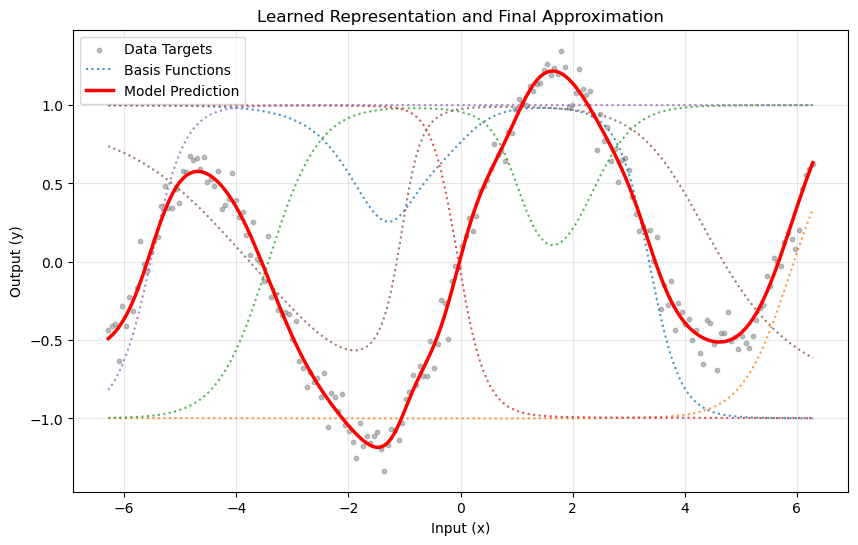

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Generation
# Target function: y = sin(x) + 0.1 * x
def target_function(x):
    return torch.sin(x) + 0.1 * x

torch.manual_seed(42)

# Generate training data
x_train = torch.linspace(-2 * np.pi, 2 * np.pi, 200).unsqueeze(1)
y_train = target_function(x_train) + 0.1 * torch.randn_like(x_train) # Add noise

# 2. Model Definition
class RepresentationLearner(nn.Module):
    def __init__(self, n_features=6):
        super().__init__()
        # Feature extractor layers (The representation learner)
        self.feature_extractor = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, n_features),
            nn.Tanh() # Penultimate layer activation
        )
        # Final linear readout
        self.final_layer = nn.Linear(n_features, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        output = self.final_layer(features)
        return output, features

model = RepresentationLearner(n_features=6)

# 3. Training Loop
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 2000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs, _ = model(x_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.5f}")

# 4. Evaluation and Visualization
model.eval()
with torch.no_grad():
    y_pred, features = model(x_train)

# Convert to numpy for plotting
x_np = x_train.numpy()
y_train_np = y_train.numpy()
y_pred_np = y_pred.numpy()
features_np = features.numpy()

# Plotting
plt.figure(figsize=(10, 6))

# Plot original data (Scatter)
plt.scatter(x_np, y_train_np, color='gray', alpha=0.5, s=10, label='Data Targets')

# Plot learned basis functions (Dotted lines)
# We plot the raw activations of the penultimate layer
num_features = features_np.shape[1]
for i in range(num_features):
    label = "Basis Functions" if i == 0 else None
    plt.plot(x_np, features_np[:, i], linestyle=':', linewidth=1.5, alpha=0.8, label=label)

# Plot model prediction (Solid curve)
plt.plot(x_np, y_pred_np, color='red', linewidth=2.5, label='Model Prediction')

plt.title("Learned Representation and Final Approximation")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)


plt.show()